**30/12/2025**

In [2]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='target')

print('X shape:', X.shape)
print('Class counts:\n', y.value_counts())
X.head()

X shape: (150, 4)
Class counts:
 target
0    50
1    50
2    50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
# Step 1
# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)

Train size: (120, 4)
Test size : (30, 4)


In [ ]:
# Step 2
# scale features (IMPORTANT for neural networks)
#SNAS: scale the data to have mean is 0

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Optional: quick check mean/std after scaling
print('After scaling (train):')
print('Mean(approx):', np.round(X_train_scaled.mean(axis=0), 3))
print('Std (approx):', np.round(X_train_scaled.std(axis=0), 3))

After scaling (train):
Mean(approx): [-0. -0.  0.  0.]
Std (approx): [1. 1. 1. 1.]


In [ ]:
# Step 3
# train an MPClassifier (simple setup)

mlp = MLPClassifier(
    hidden_layer_sizes=(10,), # 1 hidden layer with 10 neurons
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42 #SNAS: setting random state gives a starting point for your random module. even if random is there, it is not completely random.
    #SNAS: 42 is no special meaning. can put any number
)

mlp.fit(X_train_scaled, y_train)

# predict
y_pred = mlp.predict(X_test_scaled)

# accuracy
acc = accuracy_score(y_test, y_pred)

print('=== MLPClassifier on iris ===')
print('Test Accuracy:', round(acc, 4))

=== MLPClassifier on iris ===
Test Accuracy: 0.9667


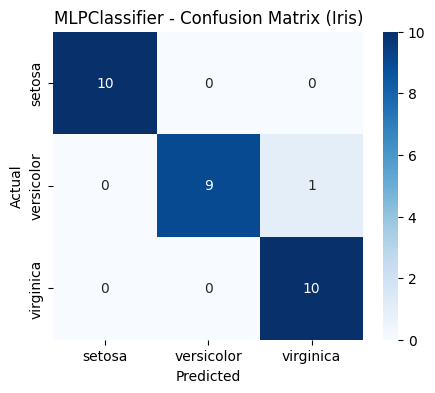

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [9]:
# Confusion matrix + classification report

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('MLPClassifier - Confusion Matrix (Iris)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test, y_pred, target_names=iris.target_names))

**Exercise 1**

Loads the Breast Cancer Wisconsin dataset (real medical data).

Splits into train/test.

Scales features.

Trains a small MLPClassifier.

Evaluates with accuracy + confusion matrix + classification report.

In [3]:
# SNAS: my answer as below

import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#1. Load dataset
# Features: measurements of cell nuclei
# Target: 0 = malignant, 1 = benign

cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

In [12]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)

Train size: (455, 30)
Test size : (114, 30)


In [13]:
# scale features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Optional: quick check mean/std after scaling
print('After scaling (train):')
print('Mean(approx):', np.round(X_train_scaled.mean(axis=0), 3))
print('Std (approx):', np.round(X_train_scaled.std(axis=0), 3))

After scaling (train):
Mean(approx): [-0.  0. -0.  0.  0. -0. -0.  0. -0. -0.  0. -0.  0. -0. -0.  0.  0.  0.
  0.  0.  0.  0. -0. -0.  0. -0. -0. -0. -0. -0.]
Std (approx): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


In [15]:
# Step 3
# train an MPClassifier (simple setup)

mlp = MLPClassifier(
    hidden_layer_sizes=(10,), # 1 hidden layer with 10 neurons
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42 #SNAS: setting random state gives a starting point for your random module. even if random is there, it is not completely random.
    #SNAS: 42 is no special meaning. can put any number
)

mlp.fit(X_train_scaled, y_train)

# predict
y_pred = mlp.predict(X_test_scaled)

# accuracy
acc = accuracy_score(y_test, y_pred)

print('=== MLPClassifier on Breast Cancer Wisconsin data ===')
print('Test Accuracy:', round(acc, 4))

=== MLPClassifier on Breast Cancer Wisconsin data ===
Test Accuracy: 0.9649


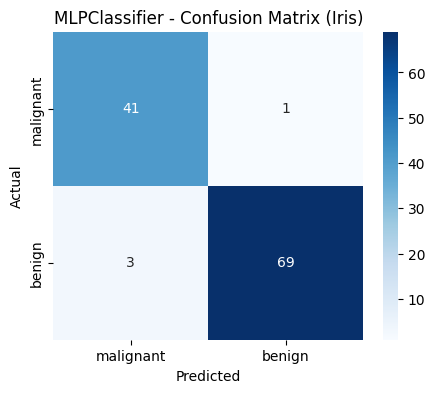

              precision    recall  f1-score   support

   malignant       0.93      0.98      0.95        42
      benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



In [17]:
# Confusion matrix + classification report

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.title('MLPClassifier - Confusion Matrix (Iris)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test, y_pred, target_names=cancer.target_names))

**31/12/2025**

In [4]:
import numpy as np

def neuron_output(x1, x2, w1, w2, b):

    #A simple neuron:
    #z = w1*x1 + w2*x2 + b
    #here we will not apply an activation yet, just return z.

    z = w1*x1 + w2*x2 + b
    return z

# Example inputs (e.g, hours studied, extra classes attended)
x1 = 5 # feature 1
x2 = 2 # feature 2

# example weights and bias
w1 = 0.8
w2 = 1.2
b = -1.0

z = neuron_output(x1, x2, w1, w2, b)
print('Linear combination (z):', z)


Linear combination (z): 5.4


In [ ]:
#SNAS: to see sir's note as my graph is not returning any data

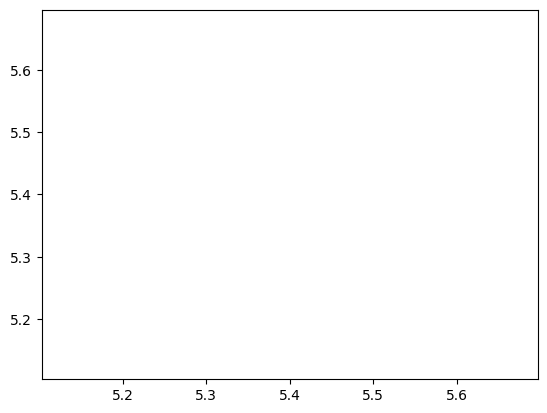

In [5]:
def relu(z):
    return np.maximum(0, z)

relu_vals = relu(z)

plt.plot(z, relu_vals, label='ReLu')

In [7]:
# 5.1 Tiny 2-layer nueral network forward pass (no training)

np.random.seed(42)

# Input: 1 features, 2 inputs
x1 = np.array([ [2],
                [1]])    # shape (2,1) 2 rows 1 column

print(f'x1:\n{x1}')

x1:
[[2]
 [1]]


In [ ]:
#Hidden layer: 3 neaurons

#W1 = np.random.randn(1, 3)  # weights for hidden layer (1x3)
#b1 = np.random.randn(1, 1)  # bias for hidden layer (1x1)

#print(f'W1:\n{W1}\nB:\n{b1}')

W:
[[ 0.49671415 -0.1382643   0.64768854]]
B:
[[1.52302986]]


In [ ]:
#SNAS: trying another method

W1 = np.random.randn(3, 2)  # weights for hidden layer (1x3)
b1 = np.random.randn(3, 1)  # bias for hidden layer (1x1)

print(f'W1:\n{W1}\nB:\n{b1}')

W1:
[[-0.23415337 -0.23413696]
 [ 1.57921282  0.76743473]
 [-0.46947439  0.54256004]]
B:
[[-0.46341769]
 [-0.46572975]
 [ 0.24196227]]


In [30]:
W2 = np.random.randn(1, 3)
b2 = np.random.randn(3, 1)

print(f'W2:\n{W2}\nB:\n{b2}')

W2:
[[ 0.11092259 -1.15099358  0.37569802]]
B:
[[-0.60063869]
 [-0.29169375]
 [-0.60170661]]


In [31]:
def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:
# Forward pass. only moving data from one end to another
# Hidden layer

z1 = np.dot(W1, x1) + b1
a1 = relu(z1)
print(f'z1:\n{z1}\na1:\n{a1}')

z1:
[[-1.1658614 ]
 [ 3.46013061]
 [-0.15442646]]
a1:
[[0.        ]
 [3.46013061]
 [0.        ]]


In [33]:
z2 = np.dot(W2, a1) + b2
a2 = sigmoid(z2)

print(f'z2:\n{z2}\na2:\n{a2}')

z2:
[[-4.5832268 ]
 [-4.27428186]
 [-4.58429472]]
a2:
[[0.01011843]
 [0.01373088]
 [0.01010774]]


In [ ]:
#SNASL to get sir's note for below. I've put sir's note already. to check whether correct or not

In [13]:
# 5.1 Tiny 2-layer neural network forward pass (no training)

np.random.seed(42)

# Input: 2 features
x = np.array([[2.0],
              [1.0]])  # shape (2, 1)

In [9]:
# Hidden layer: 3 neurons
W1 = np.random.randn(3, 2)   # weights for hidden layer (3x2)
b1 = np.random.randn(3, 1)   # bias for hidden layer (3x1)

print(f'W:\n{W1}\nB:\n{b1}')

W:
[[ 0.49671415 -0.1382643 ]
 [ 0.64768854  1.52302986]
 [-0.23415337 -0.23413696]]
B:
[[ 1.57921282]
 [ 0.76743473]
 [-0.46947439]]


In [10]:
# Output layer: 1 neuron
W2 = np.random.randn(1, 3)   # weights for output layer (1x3)
b2 = np.random.randn(1, 1)   # bias for output layer (1x1)

print(f'W2:\n{W2}\nb2:\n{b2}')

W2:
[[ 0.54256004 -0.46341769 -0.46572975]]
b2:
[[0.24196227]]


In [14]:
# Forward pass
# Hidden layer
z1 = np.dot(W1, x) + b1      # linear
a1 = relu(z1)                # activation
print(f'z1:\n{z1}\na1:\n{a1}')

z1:
[[ 2.43437682]
 [ 3.58584166]
 [-1.17191809]]
a1:
[[2.43437682]
 [3.58584166]
 [0.        ]]


In [15]:
# Output layer
z2 = np.dot(W2, a1) + b2     # linear
a2 = sigmoid(z2)             # activation (e.g., probability of class 1)

print(f'z2:\n{W2}\na2:\n{b2}')

z2:
[[ 0.54256004 -0.46341769 -0.46572975]]
a2:
[[0.24196227]]


In [16]:
def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [17]:
print("Input x:\n", x)
print("\nHidden layer linear output (z1):\n", z1)
print("\nHidden layer activation (a1, after ReLU):\n", a1)
print("\nOutput layer linear output (z2):\n", z2)
print("\nFinal output (a2, after sigmoid – can be seen as probability):\n", a2)

Input x:
 [[2.]
 [1.]]

Hidden layer linear output (z1):
 [[ 2.43437682]
 [ 3.58584166]
 [-1.17191809]]

Hidden layer activation (a1, after ReLU):
 [[2.43437682]
 [3.58584166]
 [0.        ]]

Output layer linear output (z2):
 [[-0.0989846]]

Final output (a2, after sigmoid – can be seen as probability):
 [[0.47527403]]
